In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
superstore = pd.read_csv('Superstore.csv', encoding='ISO-8859-1')
superstore.head()

,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,7981,CA-2011-103800,1/3/13,1/7/13,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,740,CA-2011-112326,1/4/13,1/8/13,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
2,741,CA-2011-112326,1/4/13,1/8/13,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
3,742,CA-2011-112326,1/4/13,1/8/13,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
4,1760,CA-2011-141817,1/5/13,1/12/13,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [11]:
# Nhóm theo vùng, tính tổng doanh thu theo vùng
sales_by_regions = superstore.groupby('Region')['Sales'].sum()
# superstoreDf = superstore.groupby('Region')
# superstoreDf.head()
print(type(sales_by_regions), sales_by_regions.head())

regions = list(sales_by_regions.index)
sales = list(sales_by_regions.values)

print(regions, sales, sep='\n')

<class 'pandas.core.series.Series'> Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64
['Central', 'East', 'South', 'West']
[np.float64(501239.8908), np.float64(678781.24), np.float64(391721.905), np.float64(725457.8245)]


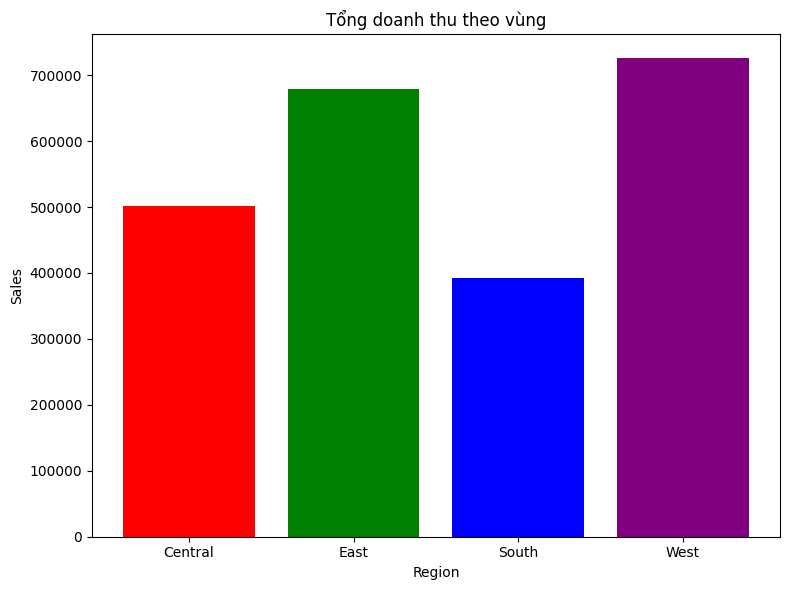

In [28]:
# Vẽ biểu đồ cột so sánh doanh thu theo vùng
plt.figure(figsize=(8,6))
plt.bar(regions, sales, color=['red', 'green', 'blue', 'purple'])
plt.title('Tổng doanh thu theo vùng')
plt.ylabel('Sales')
plt.xlabel('Region')
plt.tight_layout()
plt.show()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


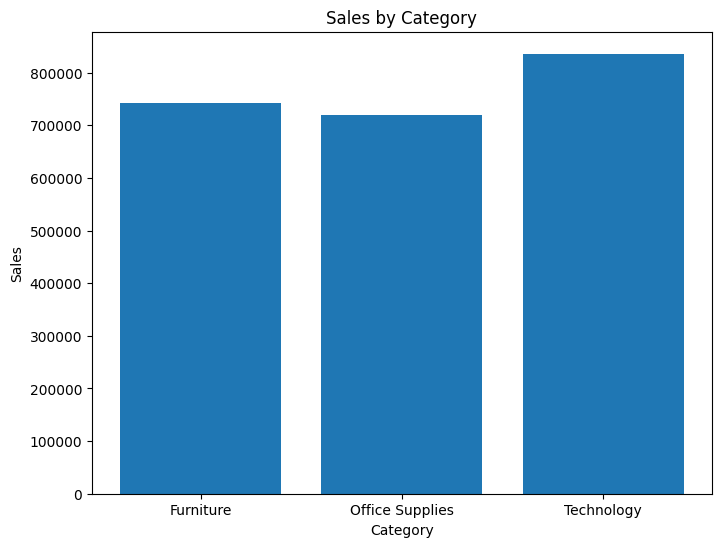

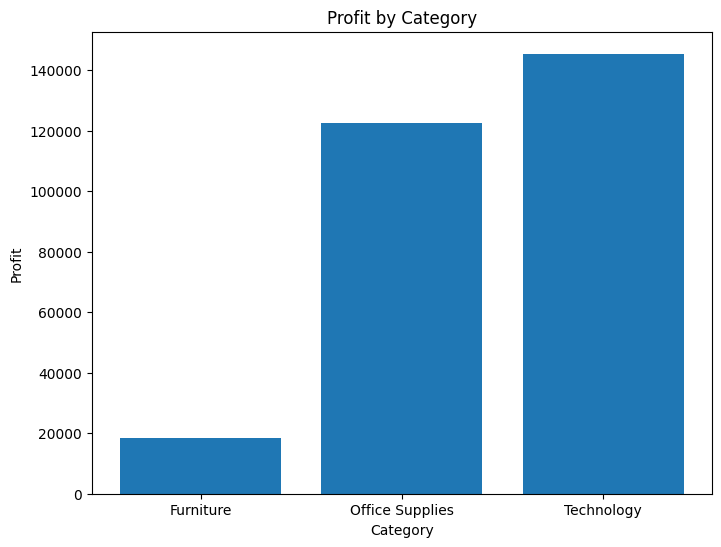

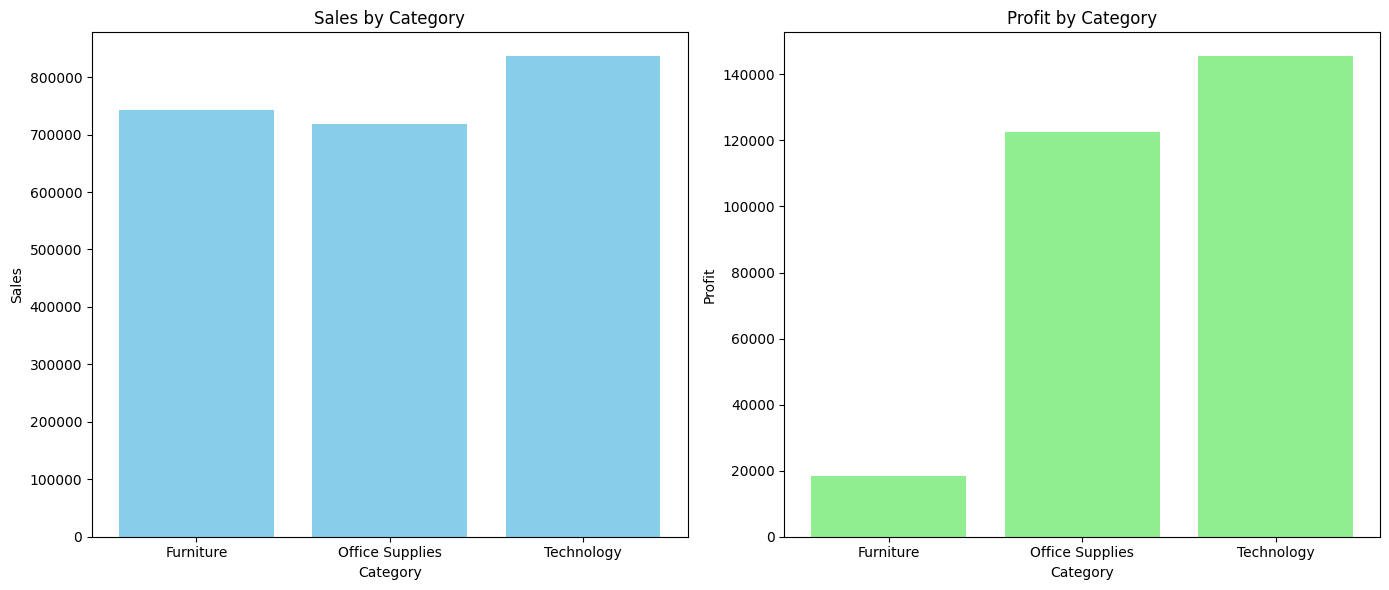

In [16]:
# TODO: Nhóm theo Category, tính tổng doanh thu theo Category và vẽ biểu đồ cột
sales_by_categories = superstore.groupby('Category')['Sales'].sum()
print(sales_by_categories)

plt.figure(figsize=(8,6))
plt.bar(sales_by_categories.index, sales_by_categories.values)
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

# TODO: Nhóm theo Category, tính tổng lợi nhuận theo Category và vẽ biểu đồ cột
profit_by_category = superstore.groupby('Category')['Profit'].sum()
plt.figure(figsize=(8,6))
plt.bar(profit_by_category.index, profit_by_category.values)
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

# TODO: Vẽ 2 biểu đồ doanh thu và lợi nhuận ở trên cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].bar(sales_by_categories.index, sales_by_categories.values, color='skyblue')
axes[0].set_title('Sales by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Sales')
axes[1].bar(profit_by_category.index, profit_by_category.values, color='lightgreen')
axes[1].set_title('Profit by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Profit')
plt.tight_layout()
plt.show()

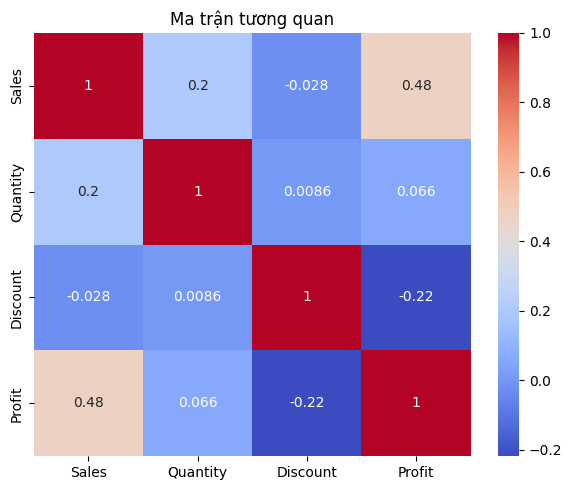

In [ ]:
# Tính ma trận tương quan cho các cột Sales, Quantity, Discount và Profit
corr_matrix = superstore[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
# TODO: Vẽ biểu đồ nhiệt đo sự tương quan

In [20]:
# Đếm số lượng Ship Mode với value_counts
shipmode_counts = superstore['Ship Mode'].value_counts()

print(type(shipmode_counts), shipmode_counts)
ship_modes = list(shipmode_counts.index)
print(type(ship_modes), ship_modes)

<class 'pandas.core.series.Series'> Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64
<class 'list'> ['Standard Class', 'Second Class', 'First Class', 'Same Day']


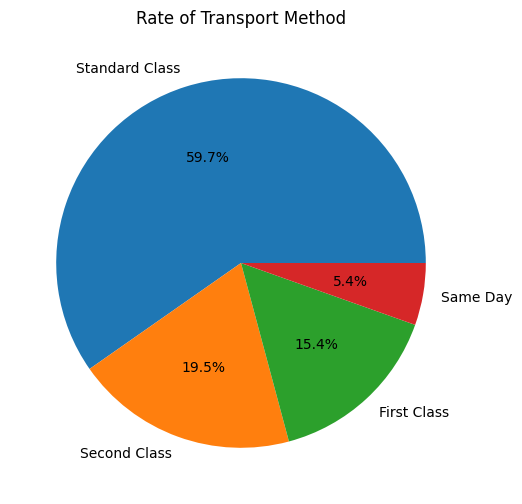

In [21]:
# TODO: Vẽ biểu đồ tròn so sánh tỉ lệ các phương thức vận chuyển

plt.figure(figsize=(8, 6))
plt.pie(x=shipmode_counts.values, labels=shipmode_counts.index, autopct='%1.1f%%')
plt.title('Rate of Transport Method')
plt.show()

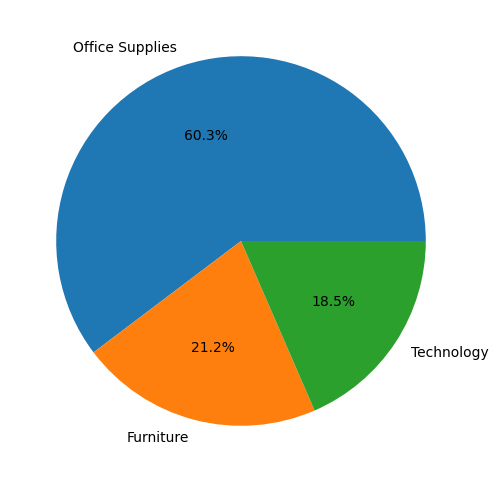

In [22]:
# TODO: Đếm số lượng Category, vẽ biểu đồ tròn so sánh số lượng các Category
categories = superstore['Category'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(x=categories.values, labels=categories.index, autopct='%1.1f%%')
plt.show()

In [2]:
transfers = pd.read_csv('transfers.csv')

# Xử lý dữ liệu: bỏ các dòng thiếu thông tin cần thiết
transfers = transfers.dropna(subset=['Age', 'Market_value', 'Transfer_fee'])

transfers.head()



C:\Users\Ryan\AppData\Local\Temp\ipykernel_12304\747384513.py:1: DtypeWarning: Columns (0,1,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  transfers = pd.read_csv('transfers.csv')


,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season,Market_value,Transfer_fee
0,Luís Figo,Right Winger,27.0,FC Barcelona,LaLiga,Real Madrid,LaLiga,2000-2001,60000000,60000000.0
1,Hernán Crespo,Centre-Forward,25.0,Parma,Serie A,Lazio,Serie A,2000-2001,56810000,56810000.0
2,Marc Overmars,Left Winger,27.0,Arsenal,Premier League,FC Barcelona,LaLiga,2000-2001,40000000,40000000.0
3,Gabriel Batistuta,Centre-Forward,31.0,Fiorentina,Serie A,AS Roma,Serie A,2000-2001,36150000,36150000.0
4,Nicolas Anelka,Centre-Forward,21.0,Real Madrid,LaLiga,Paris SG,Ligue 1,2000-2001,34500000,34500000.0


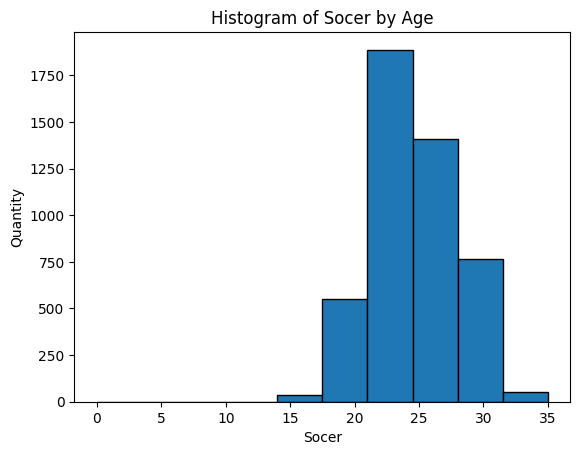

In [ ]:
# TODO: Vẽ biểu đồ histogram thể hiện phân phối độ tuổi cầu thủ

player_ages = transfers['Age']
print(type(player_ages), player_ages)
plt.title('Histogram of Socer by Age')
plt.hist(player_ages, bins=10, edgecolor='black')
plt.xlabel('Socer')
plt.ylabel('Quantity')
plt.show()




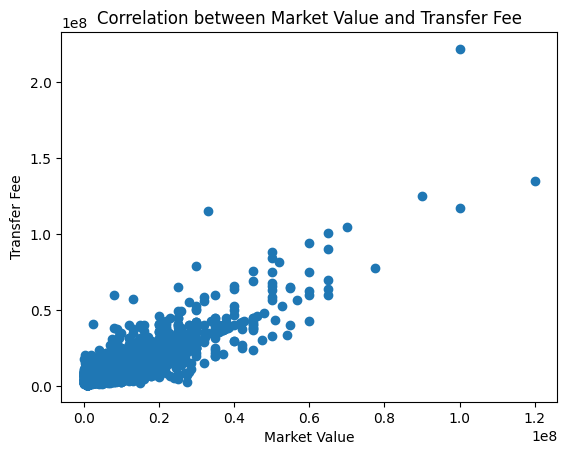

In [21]:
# TODO: Vẽ biểu đồ so sánh quan hệ giữa Market Value và Transfer Fee
market_values = transfers['Market_value']
transfer_fee = transfers['Transfer_fee']
plt.scatter(market_values, transfer_fee, alpha=1)
plt.title('Correlation between Market Value and Transfer Fee')
plt.xlabel('Market Value')
plt.ylabel('Transfer Fee')
plt.show()


<class 'pandas.core.frame.DataFrame'>


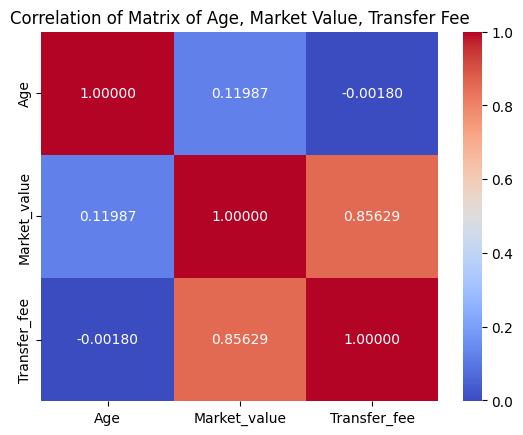

In [4]:
# TODO: Vẽ heatmap tương quan giữa Age, Market Value và Transfer Fee

Age_MarketValue_TransferFee_Df = transfers[['Age', 'Market_value', 'Transfer_fee']]
Age_MarketValue_TransferFee_Df.head()

Age_MarketValue_TransferFee_Corr = Age_MarketValue_TransferFee_Df.corr()
print(type(Age_MarketValue_TransferFee_Corr))

sns.heatmap(Age_MarketValue_TransferFee_Corr, annot=True, cmap='coolwarm', fmt='.5f')
plt.title('Correlation of Matrix of Age, Market Value, Transfer Fee')
plt.show()


In [29]:
vgsales = pd.read_csv('vgsales.csv')

# Loại bỏ các dòng thiếu dữ liệu cần thiết
vgsales = vgsales.dropna(subset=['Year', 'Genre', 'Global_Sales', 'NA_Sales', 'EU_Sales'])

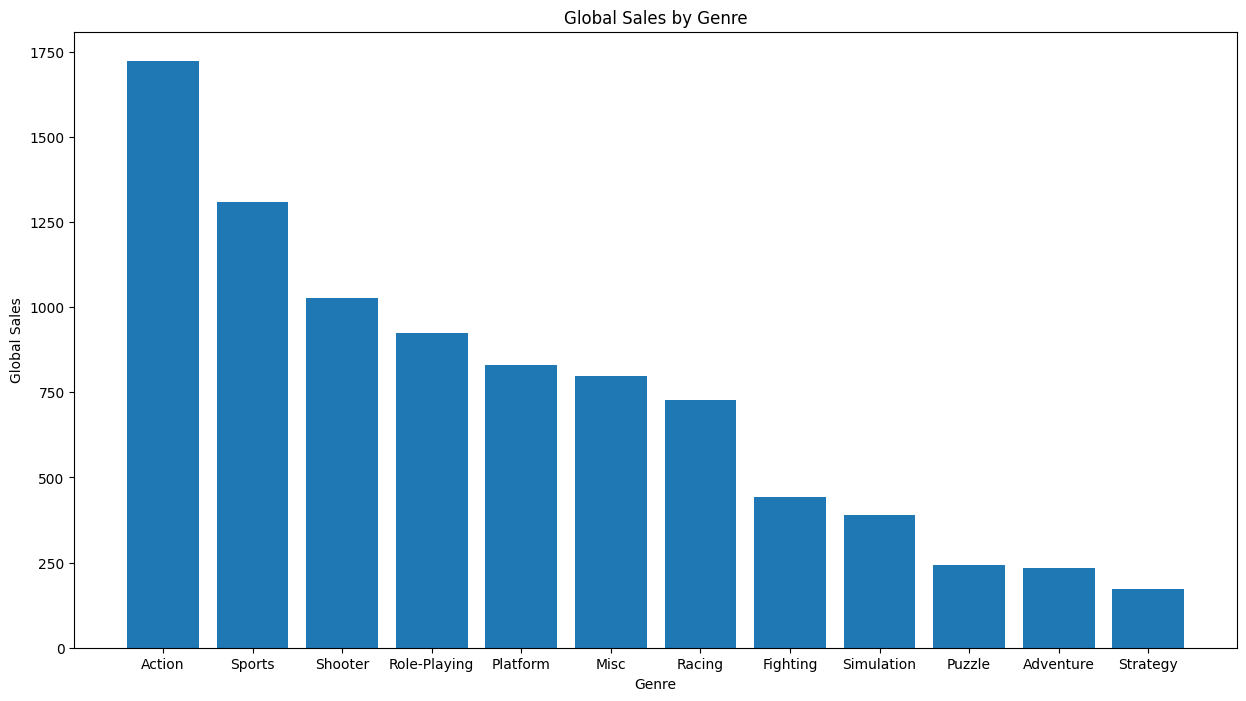

In [ ]:
# TODO: Vẽ biểu đồ cột (có sắp xếp) doanh số toàn cầu theo thể loại game (Genre)
genre_sales = vgsales.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(15,8))
plt.bar(genre_sales.index, genre_sales.values)
plt.title('Global Sales by Genre')
plt.xlabel('Genre')
plt.ylabel('Global Sales')
plt.show()

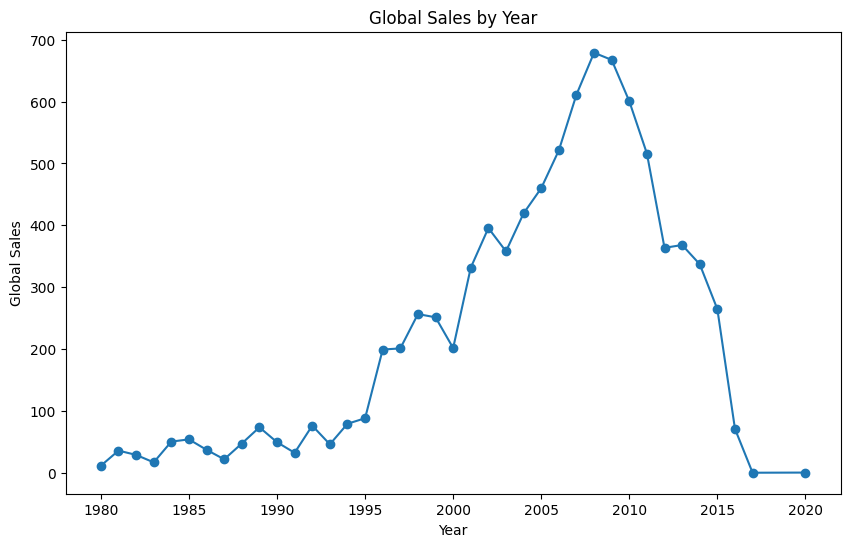

In [38]:
# TODO: Vẽ biểu đồ đường doanh số toàn cầu theo năm
yearly_sales = vgsales.groupby('Year')['Global_Sales'].sum().sort_index()
plt.figure(figsize=(10,6))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')
plt.title('Global Sales by Year')
plt.xlabel('Year')
plt.ylabel('Global Sales')
plt.show()

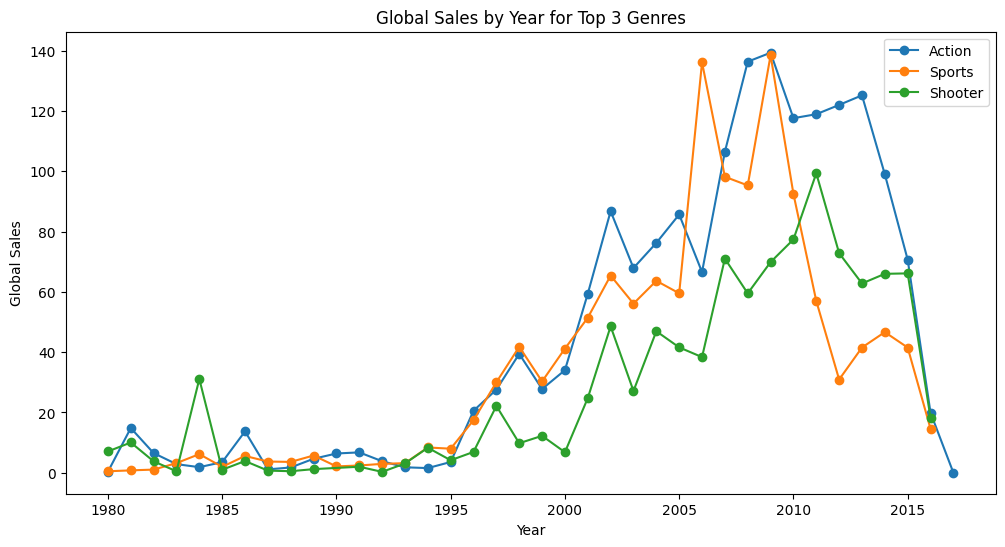

In [40]:
top3_genres = ['Action', 'Sports', 'Shooter']
top3_genres_sales = vgsales[vgsales['Genre'].isin(top3_genres)]
# TODO: Vẽ biểu đồ đường doanh số toàn cầu theo năm cho top 3 game (Action, Sports, Shooter)
plt.figure(figsize=(12,6))
for genre in top3_genres:
    genre_data = top3_genres_sales[top3_genres_sales['Genre'] == genre]
    yearly_genre_sales = genre_data.groupby('Year')['Global_Sales'].sum().sort_index()
    plt.plot(yearly_genre_sales.index, yearly_genre_sales.values, marker='o', label=genre)
plt.title('Global Sales by Year for Top 3 Genres')
plt.xlabel('Year')
plt.ylabel('Global Sales')
plt.legend()
plt.show()

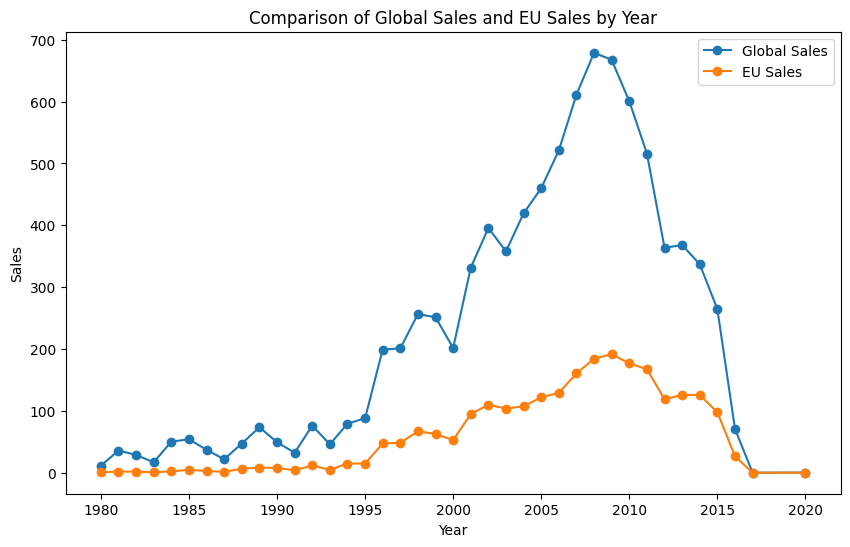

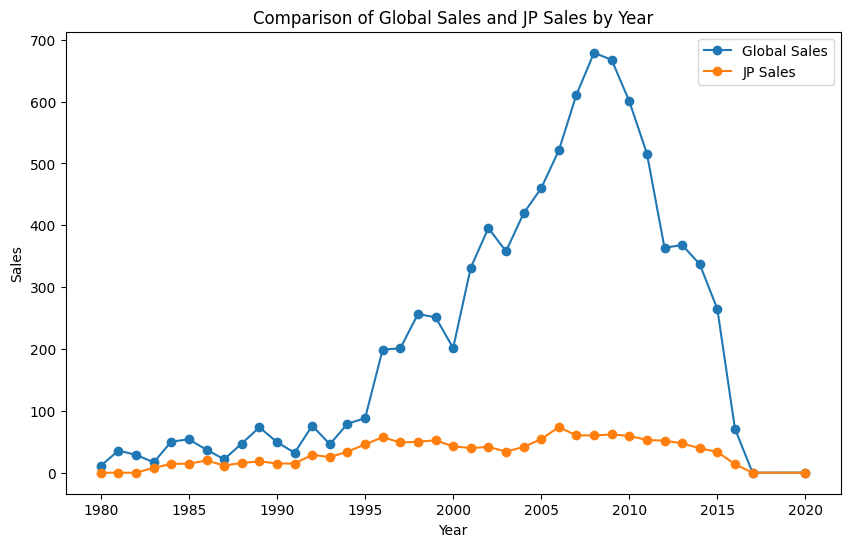

In [42]:
# TODO: So sánh mức liên quan doanh số Châu Âu và thế giới
eu_sales = vgsales.groupby('Year')['EU_Sales'].sum().sort_index()
plt.figure(figsize=(10,6))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', label='Global Sales')
plt.plot(eu_sales.index, eu_sales.values, marker='o', label='EU Sales')
plt.title('Comparison of Global Sales and EU Sales by Year')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.legend()
plt.show()

# TODO: Biểu đồ tương quan doanh số Nhật Bản và thế giới
jp_sales = vgsales.groupby('Year')['JP_Sales'].sum().sort_index()
plt.figure(figsize=(10,6))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', label='Global Sales')
plt.plot(jp_sales.index, jp_sales.values, marker='o', label='JP Sales')
plt.title('Comparison of Global Sales and JP Sales by Year')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.legend()
plt.show()